加载了 37 个数据点
Saved figure -> ./k_6_gamma0.02.pdf


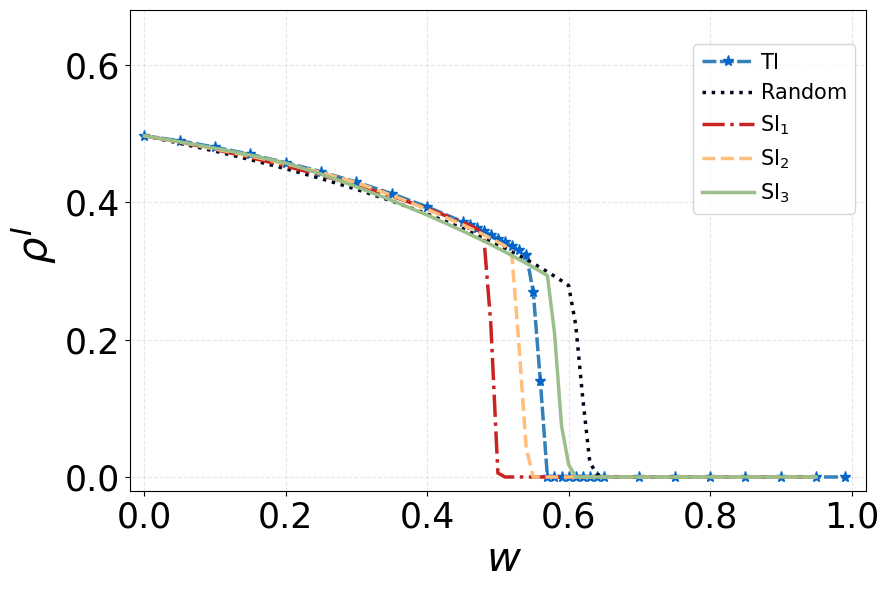

加载了 43 个数据点
Saved figure -> ./k_9_gamma0.02.pdf


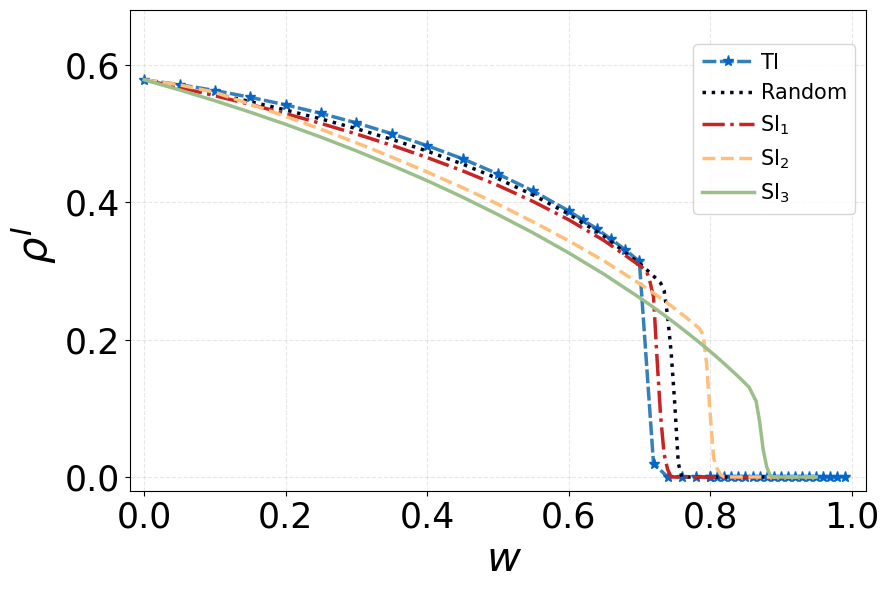

In [21]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
plot_rho_vs_w_simple.py

从 `rho_vs_w_experiment_kappa_{kappa}/rho_vs_w_summary.csv` 读取汇总数据，
绘制 ρ* (mean_rho) vs w_budget 的曲线，比较不同的 theta_del（Θ）与 random 对照。

输出:
  rho_vs_w_experiment_kappa_{kappa}/rho_vs_w_plot.png
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 配置 ----------
kappa_list = [6.0,9.0]  # 要绘制的 kappa 值列表

# 颜色和样式（可按需改）
colors = ['#03071e', "#c82423", '#ffbe7a', "#9bbf8a",]
markers = ['o', 's', '^', 'D', 'v', 'P']
linestyles = [':', '-.', '--', '-']

# ---------- 遍历每个 kappa 值并绘制图形 ----------
for kappa in kappa_list:
    OUT_DIR = f"rho_vs_w_experiment_kappa_{int(kappa)}"  # 根据 kappa 设置输出目录
    SUMMARY_FN = os.path.join(OUT_DIR, "rho_vs_w_summary.csv")
    summary_fn = os.path.join(OUT_DIR, "rho_vs_w_top_summary.csv")

   

    # ---------- 读取top数据 ----------
    summary_df = pd.read_csv(summary_fn)
    print(f"加载了 {len(summary_df)} 个数据点")


    # ---------- 读取theta_del数据 ----------
    if not os.path.exists(SUMMARY_FN):
        print(f"Warning: Summary file not found: {SUMMARY_FN}")
        continue

    df = pd.read_csv(SUMMARY_FN)

    # 兼容：有的脚本把 w 列名叫 'w' 或 'w_budget'，优先使用 w_budget
    if 'w_budget' not in df.columns and 'w' in df.columns:
        df = df.rename(columns={'w': 'w_budget'})

    # 检查必须列
    required = {'deletion_type', 'theta_del', 'w_budget', 'mean_rho', 'std_rho'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in summary CSV: {missing}")

    # ---------- 生成用于绘图的标签列 ----------
    # 如果 deletion_type 是 'random' 则标记为 'random'，否则用 SI_i 标签（保留两位小数）
    # ---------- 生成用于绘图的标签列 ----------
    def make_label(row):
        if str(row['deletion_type']).lower() == 'random':
            return r'$\mathrm{Random}$'
        # 若 theta_del 为 NaN（安全起见），也标为 random
        try:
            if pd.isna(row['theta_del']):
                return r'$\mathrm{Random}$'
        except:
            pass
        
        # 根据具体的 theta_del 值分配标签
        theta_val = float(row['theta_del'])
        if theta_val == 0.2:
            return r'$\mathrm{SI_1}$'
        elif theta_val == 0.4:
            return r'$\mathrm{SI_2}$'
        elif theta_val == 0.6:
            return r'$\mathrm{SI_3}$'
        else:
            # 对于其他值，可以返回原始值或默认标签
            return f'SI_{theta_val}'

    df['theta_label'] = df.apply(make_label, axis=1)

    
    plt.figure(figsize=(9,6))
    # ---------- 为  Top_label 绘制曲线 ----------
    plt.plot(summary_df['w_budget'], summary_df['mean_rho'], linestyle =(0, (4, 1)), marker='*', 
                    markerfacecolor='#0466c8', markeredgecolor='#0466c8',
                    linewidth=2.5, markersize=8, label=r'$\mathrm{TI}$', color='#3480b8')
 
    # ---------- 为每个 theta_label 绘制曲线 ----------
    labels = sorted(df['theta_label'].unique(), key=lambda x: (0 if x=='random' else 1, x))  # 把 'random' 放最后
    for i, label in enumerate(labels):
        sub = df[df['theta_label'] == label].copy()
        if sub.empty:
            continue
        # 确保按 w_budget 升序
        sub = sub.sort_values('w_budget')
        x = sub['w_budget'].to_numpy()
        y = sub['mean_rho'].to_numpy()
        # std 列可能全为 NaN（比如重复数=1），用 0 代替
        if 'std_rho' in sub.columns:
            yerr = sub['std_rho'].fillna(0.0).to_numpy()
        else:
            yerr = np.zeros_like(y)

        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        linestyle = linestyles[i % len(linestyles)]
        # plt.plot(x, y, label=label, color=color, marker=marker, linewidth=2, markersize=6)
        # print(x)
        plt.plot(x, y, label=label, color=color, linestyle=linestyle, linewidth=2.5, )
        # 绘制阴影带（均值 ± std）
        # if np.any(yerr > 0):
        #     plt.fill_between(x, y - yerr, y + yerr, alpha=alpha_fill, color=color)

    # ---------- 图形美化 ----------
    plt.xlabel(r" $w$ ", fontsize=30)
    plt.ylabel(r" $ρ^I$ ", fontsize=30)
    # plt.title(fr"$\kappa = {int(kappa)}, \gamma = 0.02$", fontsize=25)  # 添加 kappa 标题
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 0.68)
    plt.xticks(np.linspace(0,1,6), fontsize=25)
    plt.yticks(np.arange(0,0.8,0.2), fontsize=25)
    plt.grid(alpha=0.3, linestyle='--', linewidth=0.8)

    legend = plt.legend(
        loc='upper right',
        bbox_to_anchor=(1, 0.95),
        fontsize='15',
        handletextpad=0.3,    # 图标与文本的间距
        #columnspacing=1,      # 列间距（多列时有效）
        borderpad=0.4,          # 图例内边距
        # ncol=2,              # 分两列
        handlelength=2.5,    # 统一图标宽度
        columnspacing=0.5,     # 缩小列间距（默认2.0）
    )
    plt.tight_layout()

    # ---------- 保存并显示 ----------
    FIG_FN = os.path.join("./", f"k_{int(kappa)}_gamma0.02.pdf")
    plt.savefig(FIG_FN, dpi=300, bbox_inches='tight')
    print(f"Saved figure -> {FIG_FN}")
    plt.show()

Saved figure -> ./k_6_gamma0.03.pdf


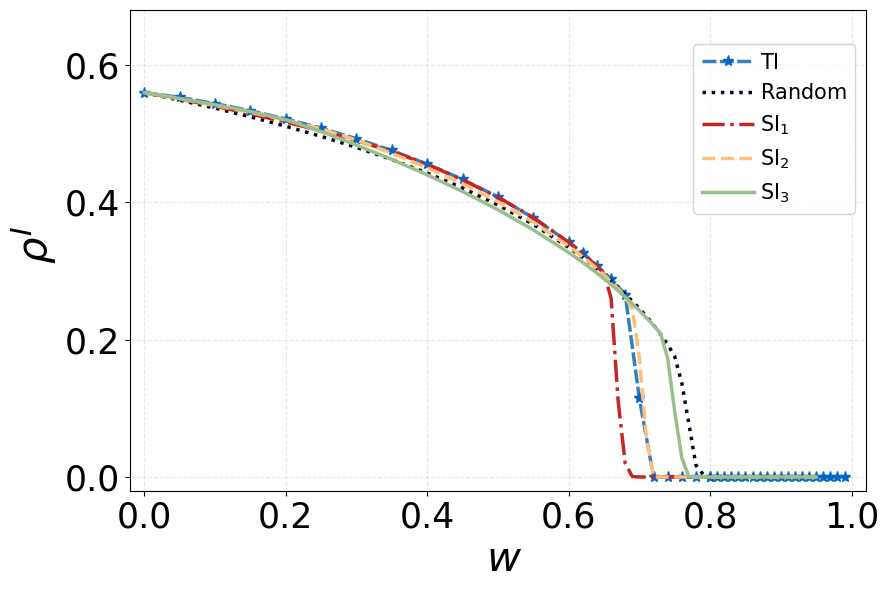

Saved figure -> ./k_9_gamma0.03.pdf


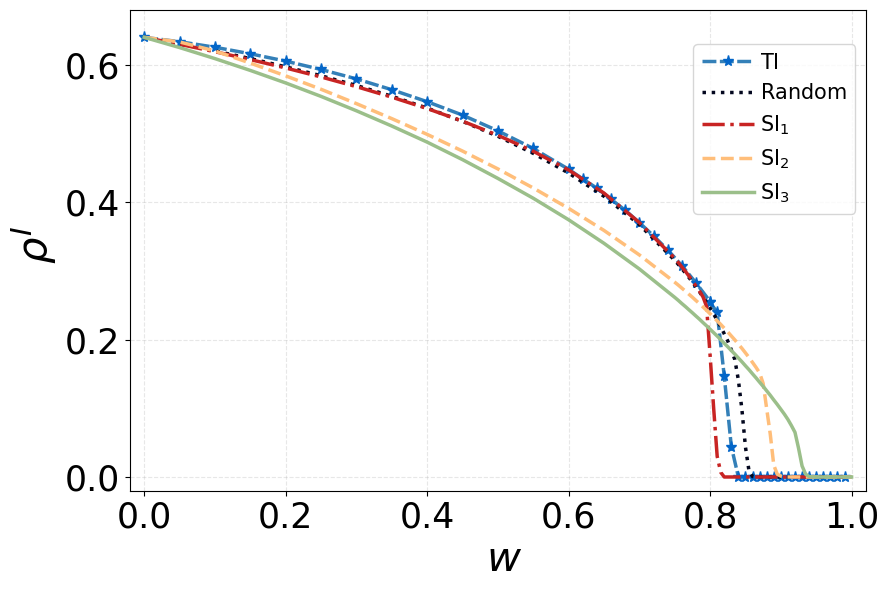

In [22]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
plot_rho_vs_w_simple.py

从 `rho_vs_w_experiment_kappa_{kappa}/rho_vs_w_summary.csv` 读取汇总数据，
绘制 ρ* (mean_rho) vs w_budget 的曲线，比较不同的 theta_del（Θ）与 random 对照。

输出:
  rho_vs_w_experiment_kappa_{kappa}/rho_vs_w_plot.png
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 配置 ----------
kappa_list = [6.0,9.0]  # 要绘制的 kappa 值列表

# 颜色和样式（可按需改）
colors = ['#03071e', "#c82423", '#ffbe7a', "#9bbf8a",]
markers = ['o', 's', '^', 'D', 'v', 'P']
linestyles = [':', '-.', '--', '-']

# ---------- 遍历每个 kappa 值并绘制图形 ----------
for kappa in kappa_list:
    OUT_DIR = f"rho_vs_w_experiment_k{int(kappa)}_0.03"  # 根据 kappa 设置输出目录
    SUMMARY_FN = os.path.join(OUT_DIR, "rho_vs_w_summary.csv")
    summary_fn = os.path.join(OUT_DIR, "rho_vs_w_top_summary.csv")



    # ---------- 读取数据 ----------

    summary_df_top = pd.read_csv(summary_fn)

    if not os.path.exists(SUMMARY_FN):
        print(f"Warning: Summary file not found: {SUMMARY_FN}")
        continue

    df = pd.read_csv(SUMMARY_FN)

    # 兼容：有的脚本把 w 列名叫 'w' 或 'w_budget'，优先使用 w_budget
    if 'w_budget' not in df.columns and 'w' in df.columns:
        df = df.rename(columns={'w': 'w_budget'})

    # 检查必须列
    required = {'deletion_type', 'theta_del', 'w_budget', 'mean_rho', 'std_rho'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in summary CSV: {missing}")

    # ---------- 生成用于绘图的标签列 ----------
    # 如果 deletion_type 是 'random' 则标记为 'random'，否则用 Θ=xx 标签（保留两位小数）
    def make_label(row):
        if str(row['deletion_type']).lower() == 'random':
            return r'$\mathrm{Random}$'
        # 若 theta_del 为 NaN（安全起见），也标为 random
        try:
            if pd.isna(row['theta_del']):
                return r'$\mathrm{Random}$'
        except:
            pass
        
        # 根据具体的 theta_del 值分配标签
        theta_val = float(row['theta_del'])
        if theta_val == 0.2:
            return r'$\mathrm{SI_1}$'
        elif theta_val == 0.4:
            return r'$\mathrm{SI_2}$'
        elif theta_val == 0.6:
            return r'$\mathrm{SI_3}$'
        else:
            # 对于其他值，可以返回原始值或默认标签
            return f'SI_{theta_val}'

    df['theta_label'] = df.apply(make_label, axis=1)


    # ---------- 为每个 top 绘制曲线 ----------
    plt.figure(figsize=(9,6))

    plt.plot(summary_df_top['w_budget'], summary_df_top['mean_rho'], linestyle =(0, (4, 1)), marker='*', 
                    markerfacecolor='#0466c8', markeredgecolor='#0466c8',
                    linewidth=2.5, markersize=8, label=r'$\mathrm{TI}$', color='#3480b8')
    # ---------- 为每个 theta_label 绘制曲线 ----------
    labels = sorted(df['theta_label'].unique(), key=lambda x: (0 if x=='random' else 1, x))  # 把 'random' 放最后
    for i, label in enumerate(labels):
        sub = df[df['theta_label'] == label].copy()
        if sub.empty:
            continue
        # 确保按 w_budget 升序
        sub = sub.sort_values('w_budget')
        x = sub['w_budget'].to_numpy()
        y = sub['mean_rho'].to_numpy()
        # std 列可能全为 NaN（比如重复数=1），用 0 代替
        if 'std_rho' in sub.columns:
            yerr = sub['std_rho'].fillna(0.0).to_numpy()
        else:
            yerr = np.zeros_like(y)

        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        linestyle = linestyles[i % len(linestyles)]
        # plt.plot(x, y, label=label, color=color, marker=marker, linewidth=2, markersize=6)
        plt.plot(x, y, label=label, color=color, linestyle=linestyle, linewidth=2.5, )
        # 绘制阴影带（均值 ± std）
        # if np.any(yerr > 0):
        #     plt.fill_between(x, y - yerr, y + yerr, alpha=alpha_fill, color=color)

    # ---------- 图形美化 ----------
    plt.xlabel(r" $w$ ", fontsize=30)
    plt.ylabel(r" $ρ^I$ ", fontsize=30)
    # plt.title(fr"$\kappa = {int(kappa)}, \gamma = 0.03$", fontsize=25)  # 添加 kappa 标题
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 0.68)
    plt.xticks(np.linspace(0,1,6), fontsize=25)
    plt.yticks(np.arange(0,0.8,0.2), fontsize=25)
    plt.grid(alpha=0.3, linestyle='--', linewidth=0.8)

    legend = plt.legend(
        loc='upper right',
        bbox_to_anchor=(1, 0.95),
        fontsize='15',
        handletextpad=0.3,    # 图标与文本的间距
        #columnspacing=1,      # 列间距（多列时有效）
        borderpad=0.4,          # 图例内边距
        # ncol=2,              # 分两列
        handlelength=2.5,    # 统一图标宽度
        columnspacing=0.5,     # 缩小列间距（默认2.0）
    )
    plt.tight_layout()

    # ---------- 保存并显示 ----------
    FIG_FN = os.path.join("./", f"k_{int(kappa)}_gamma0.03.pdf")
    plt.savefig(FIG_FN, dpi=300, bbox_inches='tight')
    print(f"Saved figure -> {FIG_FN}")
    plt.show()

In [23]:
w_list = np.concatenate([
    np.arange(0.0, 0.45, 0.05),
    np.arange(0.45, 0.7, 0.05),
    np.arange(0.7, 0.9, 0.005),
    np.arange(0.9, 1.0, 0.05),
])

print(w_list)

# 查看实际值
a4 = np.arange(0.9, 1.0, 0.05)
print("第四个区间的实际值:", a4)
print("数据类型:", a4.dtype)

a5 = np.arange(0.7, 0.9, 0.05)
print("第五个区间的实际值:", a5)
print("数据类型:", a5.dtype)

[0.    0.05  0.1   0.15  0.2   0.25  0.3   0.35  0.4   0.45  0.5   0.55
 0.6   0.65  0.7   0.705 0.71  0.715 0.72  0.725 0.73  0.735 0.74  0.745
 0.75  0.755 0.76  0.765 0.77  0.775 0.78  0.785 0.79  0.795 0.8   0.805
 0.81  0.815 0.82  0.825 0.83  0.835 0.84  0.845 0.85  0.855 0.86  0.865
 0.87  0.875 0.88  0.885 0.89  0.895 0.9   0.9   0.95 ]
第四个区间的实际值: [0.9  0.95]
数据类型: float64
第五个区间的实际值: [0.7  0.75 0.8  0.85 0.9 ]
数据类型: float64


In [24]:
w_list = np.concatenate([
    np.arange(0.0, 0.45, 0.05),
    np.arange(0.45, 0.7, 0.05),
    np.arange(0.7, 0.9, 0.005),
    np.linspace(0.9, 0.95, 2)  # 明确指定起点、终点和点数
])
print(w_list)

[0.    0.05  0.1   0.15  0.2   0.25  0.3   0.35  0.4   0.45  0.5   0.55
 0.6   0.65  0.7   0.705 0.71  0.715 0.72  0.725 0.73  0.735 0.74  0.745
 0.75  0.755 0.76  0.765 0.77  0.775 0.78  0.785 0.79  0.795 0.8   0.805
 0.81  0.815 0.82  0.825 0.83  0.835 0.84  0.845 0.85  0.855 0.86  0.865
 0.87  0.875 0.88  0.885 0.89  0.895 0.9   0.9   0.95 ]
